In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
mhiro2_pytorch_pretrained_models_path = kagglehub.dataset_download('mhiro2/pytorch-pretrained-models')

print('Data source import complete.')


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


100%|██████████| 9.59G/9.59G [07:33<00:00, 22.7MB/s]

Extracting files...


Data source import complete.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<h1 style="font-family:verdana;"> <center>📚 Pneumonia Detection using Resnet101 Transfer Learning📚</center> </h1>
<p><center style="color:#159364; font-family:cursive;">In this notebook, I have evaluated the performance of Resnet101 Architecture by fine-tuning it on <code>Chest X-Ray Images(Pneumonia)</code> Dataset.</center></p>
    <center>
<div class="alert alert-block alert-info" style="font-size:14px; font-family:verdana; line-height: 1.7em;">
    📌 &nbsp; In case this notebook is helpful to you in anyway, please do consider upvoting :)
</div></center>

***

# 🎯 Resnet Model
<div style="text-align:center;">
    <img  src="https://www.researchgate.net/publication/343374745/figure/fig3/AS:922661106503680@1596990958634/Workflow-diagram-a-Typical-architecture-of-the-101-layer-ResNet-b-The-flowchart-of.png" />
</div>
ResNet, short for Residual Networks, is a classic neural network used as a backbone for many computer vision tasks. This model was proposed by Kaiming He, Xiangyu Zhang, Shaoqing Ren, and Jian Sun in their 2015 paper, "Deep Residual Learning for Image Recognition".

## Key Features of ResNet:

1. 📏 **Depth**: ResNet models are significantly deeper than their predecessors. The model comes in different variants including ResNet-18, ResNet-34, ResNet-50, ResNet-101, and ResNet-152, where the numbers denote layers. Deeper networks are able to learn more complex patterns.

2. 🔄 **Residual Blocks**: ResNet introduced the concept of residual blocks, which include skip connections, or shortcuts to jump over some layers. This helps solve the vanishing gradient problem during training.

3. 🍾 **Bottleneck Design**: For each residual block, ResNet uses a bottleneck design with three layers: 1x1, 3x3, and 1x1 convolutions. The 1x1 convolutions are responsible for reducing and then increasing (restoring) dimensions, leaving the 3x3 convolution a bottleneck with smaller input/output dimensions.

4. 🎯 **Identity Shortcut Connection**: These are used to directly connect the input of the residual block to its output. This connection ensures that the underlying identity mapping is learned, which aids in optimizing the network.

5. 🌐 **Global Average Pooling**: Instead of using fully connected layers, ResNet uses global average pooling before the final classification layer, which minimizes overfitting.

6. 🔥 **Activation Function**: The activation function used in the ResNet model is the Rectified Linear Unit (ReLU).



# 📚 Import Libraries


In [3]:
%matplotlib inline
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
import skimage
from skimage import io, transform
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms

# 📂 Load Dataset

The dataset respective to already classified category is divided into three sets:
* test set
* train set
* validation set


In [4]:
EPOCHS = 10
data_dir = "/content/drive/MyDrive/chest_xray"
TEST = 'test'
TRAIN = 'train'
VAL ='val'

# 🚀 Data Preprocessing and Augmentation

Deep learning models typically require a substantial amount of data for training. Generally, the more data available, the better the model's performance. 📈

**Image Augmentation** 🎨 is a technique used to generate new images for training our deep learning model. These new images are created using the existing training images, eliminating the need for manual collection.

In [5]:
# Define a function for data transformations
def data_transforms(phase):
    # If the phase is TRAIN
    if phase == TRAIN:
        # Compose transformations: Resize, CenterCrop, Convert to Tensor, Normalize
        transform = transforms.Compose([
            transforms.Resize(256),  # Resize the image to 256x256 pixels
            transforms.CenterCrop(224),  # Crop the center of the image to 224x224 pixels
            transforms.RandomHorizontalFlip(),  # Randomly flip the image horizontally
            transforms.ToTensor(),  # Convert the image to a PyTorch Tensor
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # Normalize the Tensor
        ])

    # If the phase is VAL
    if phase == VAL:
        # Apply the same transformations as the TRAIN phase
        transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    # If the phase is TEST
    if phase == TEST:
        # Apply the same transformations as the TRAIN phase
        transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    return transform  # Return the composed transformations

# Check if CUDA is available and set the device accordingly
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)  # Print the device being used


cuda:0


In [6]:
# Create a dictionary of datasets for each phase (TRAIN, VAL, TEST)
# For each phase, load the images from the corresponding folder and apply the data transformations
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms(x))
                  for x in [TRAIN, VAL, TEST]}

# Create a dictionary of dataloaders for each phase
# For each phase, create a DataLoader that loads the data from the corresponding dataset
# The batch size and shuffle parameters can be adjusted as needed
dataloaders = {
    TRAIN: torch.utils.data.DataLoader(image_datasets[TRAIN], batch_size = 4, shuffle=True),
    VAL: torch.utils.data.DataLoader(image_datasets[VAL], batch_size = 1, shuffle=True),
    TEST: torch.utils.data.DataLoader(image_datasets[TEST], batch_size = 1, shuffle=True)
}

In [7]:
len(dataloaders[TRAIN])

1304

In [8]:
# Get the sizes of the datasets
dataset_sizes = {
    x: len(image_datasets[x])
    for x in [TRAIN, VAL]
}

# Get the classes from the training dataset
classes = image_datasets[TRAIN].classes

# Get the class names from the training dataset
class_names = image_datasets[TRAIN].classes


# 🖼️Visualizing the Chest X-rays

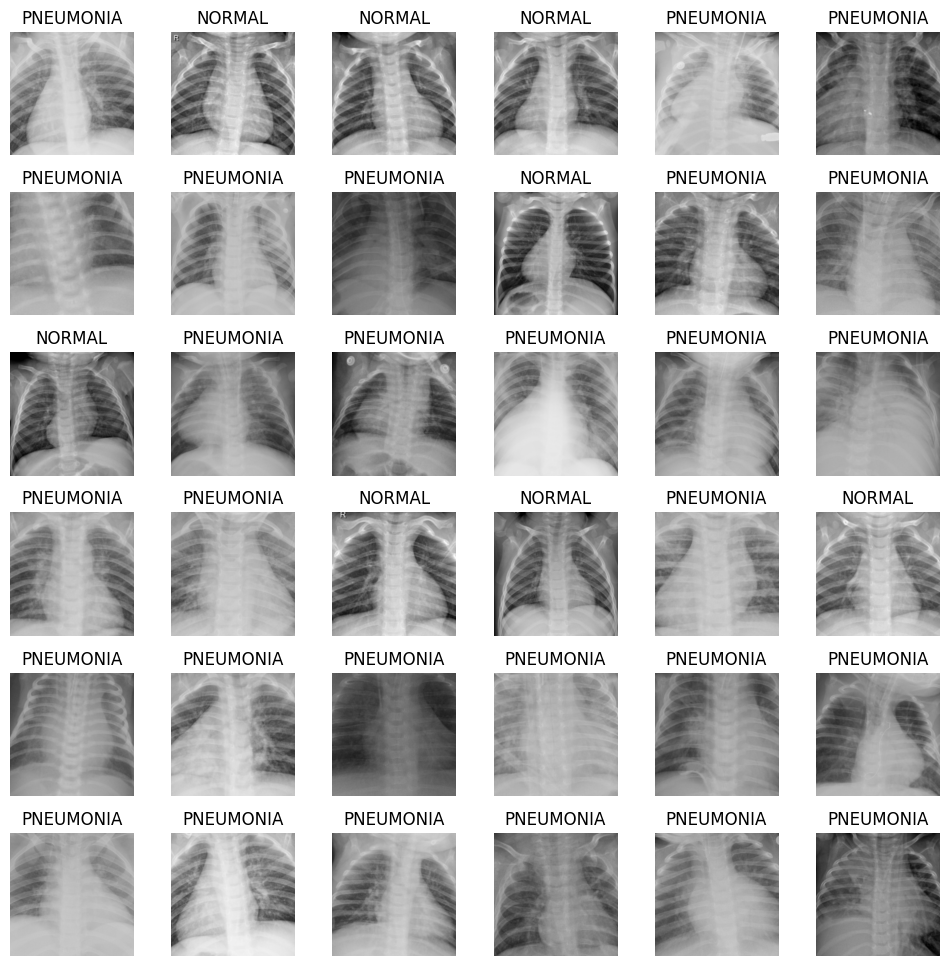

In [9]:
fig, axes = plt.subplots(6, 6, figsize=(12, 12))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

for i in range(6):
    for j in range(6):
        inputs, classes = next(iter(dataloaders[TRAIN]))
        input_img = inputs[0]
        class_label = classes[0]
        inp = input_img.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        inp = std * inp + mean
        inp = np.clip(inp, 0, 1)
        axes[i, j].imshow(inp)
        axes[i, j].set_title(class_names[class_label.item()])
        axes[i, j].axis('off')

plt.show()


In [10]:
inputs, classes = next(iter(dataloaders[TRAIN]))

# 🚀Define Function for Training


In [11]:
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    # Save the initial model weights
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Loop over the number of epochs
    for epoch in range(num_epochs):
        print("Epoch: {}/{}".format(epoch+1, num_epochs))
        print("="*10)

        # Each epoch has a training and validation phase
        for phase in [TRAIN, VAL]:
            if phase == TRAIN:
                scheduler.step()
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for data in dataloaders[phase]:
                inputs, labels = data
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase==TRAIN):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass and optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            # Deep copy the model if we have a new best validation accuracy
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    print('Best val Acc: {:4f}'.format(best_acc))

    # Load best model weights and return the model
    model.load_state_dict(best_model_wts)
    return model


# 🔄Load the Pretrained Model

In [13]:
model_pre = models.resnet101()
# To debug the FileNotFoundError, let's inspect the contents of the downloaded path:
import os
print(os.listdir(mhiro2_pytorch_pretrained_models_path))
# Once the correct path/filename is identified, modify the line below if needed.
model_pre.load_state_dict(torch.load(os.path.join(mhiro2_pytorch_pretrained_models_path, "resnet101-5d3b4d8f.pth"), weights_only=False))

['dpn68b_extra-363ab9c19.pth', 'inceptionv4-8e4777a0.pth', 'nasnetamobile-7e03cead.pth', 'repository', 'resnet101-5d3b4d8f.pth', 'fbresnet152-2e20f6b4.pth', 'pnasnet5large-bf079911.pth', 'densenet201-5750cbb1e.pth', 'inceptionresnetv2-520b38e4.pth', 'resnet50-19c8e357.pth', 'squeezenet1_1-f364aa15.pth', 'vgg13_bn-abd245e5.pth', 'vgg13-c768596a.pth', 'alexnet-owt-4df8aa71.pth', 'dpn68-4af7d88d2.pth', 'vgg11_bn-6002323d.pth', 'resnet152-b121ed2d.pth', 'resnext101_64x4d-e77a0586.pth', 'vgg16_bn-6c64b313.pth', 'dpn107_extra-b7f9f4cc9.pth', 'nasnetalarge-a1897284.pth', 'se_resnet101-7e38fcc6.pth', 'resnet18-5c106cde.pth', 'vgg16-397923af.pth', 'vgg19-dcbb9e9d.pth', 'dpn92_extra-fda993c95.pth', 'inception_v3_google-1a9a5a14.pth', 'se_resnet50-ce0d4300.pth', 'dpn98-722954780.pth', 'squeezenet1_0-a815701f.pth', 'polynet-f71d82a5.pth', 'bn_inception-52deb4733.pth', 'se_resnet152-d17c99b7.pth', 'dpn131-7af84be88.pth', 'densenet121-fbdb23505.pth', 'senet154-c7b49a05.pth', 'se_resnext101_32x4d-3b2

<All keys matched successfully>

In [14]:
for param in model_pre.parameters():
    param.requires_grad = False

model_pre.fc = nn.Sequential(
               nn.Linear(2048, 128),
               nn.ReLU(inplace=True),
               nn.Linear(128, 2)).to(device)
print(model_pre)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# 🔧Define the Hyperparameters

In [15]:
model_pre = model_pre.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_pre.parameters(), lr=0.001, momentum=0.9, weight_decay=0.01)
# Decay LR by a factor of 0.1 every 10 epochs
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# 🚂Train Phase

In [16]:
model_pre = train_model(model_pre, criterion, optimizer, exp_lr_scheduler, num_epochs=EPOCHS)

Epoch: 1/10


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


train Loss: 0.3093 Acc: 0.8675
val Loss: 1.2828 Acc: 0.5625
Epoch: 2/10
train Loss: 0.2553 Acc: 0.8970
val Loss: 0.7340 Acc: 0.7500
Epoch: 3/10
train Loss: 0.2626 Acc: 0.8953
val Loss: 0.8886 Acc: 0.6250
Epoch: 4/10
train Loss: 0.2543 Acc: 0.8928
val Loss: 1.7601 Acc: 0.5000
Epoch: 5/10
train Loss: 0.2441 Acc: 0.9011
val Loss: 0.6385 Acc: 0.7500
Epoch: 6/10
train Loss: 0.2297 Acc: 0.9068
val Loss: 0.5819 Acc: 0.6875
Epoch: 7/10
train Loss: 0.2259 Acc: 0.9082
val Loss: 1.3584 Acc: 0.6250
Epoch: 8/10
train Loss: 0.2515 Acc: 0.8997
val Loss: 0.5190 Acc: 0.6875
Epoch: 9/10
train Loss: 0.2363 Acc: 0.9026
val Loss: 0.7001 Acc: 0.7500
Epoch: 10/10
train Loss: 0.2017 Acc: 0.9195
val Loss: 1.2631 Acc: 0.7500
Best val Acc: 0.750000


In [17]:
import torch

# Definieren Sie den Pfad in Ihrem Google Drive
# Das Modell wird in Ihrem Hauptordner "MyDrive" gespeichert.
save_path = '/content/drive/MyDrive/pneumonia_resnet101_best_model.pth'

# Speichert nur die gelernten Gewichte (den state_dict) des besten Modells
torch.save(model_pre.state_dict(), save_path)

print(f"Das beste trainierte Modell wurde gespeichert unter: {save_path}")

Das beste trainierte Modell wurde gespeichert unter: /content/drive/MyDrive/pneumonia_resnet101_best_model.pth


# 📊Evaluate Model Performance


In [18]:
def test_model():
    # Initialize counters
    running_correct = 0.0
    running_total = 0.0
    true_labels = []
    pred_labels = []
    input_images = []

    # No need to track gradients for testing
    with torch.no_grad():
        # Iterate over test data
        for data in dataloaders[TEST]:
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Store true labels
            true_labels.append(labels.item())

            #Store model input images
            input_images.append(inputs)

            # Forward pass
            outputs = model_pre(inputs)
            _, preds = torch.max(outputs.data, 1)

            # Store predicted labels
            pred_labels.append(preds.item())

            # Update counters
            running_total += labels.size(0)
            running_correct += (preds == labels).sum().item()

        # Calculate accuracy
        acc = running_correct / running_total

    return true_labels, pred_labels, input_images,  running_correct, running_total, acc


# 🧪Testing Phase

In [19]:
true_labels, pred_labels, input_images, running_correct, running_total, acc = test_model()

# 📈 Results

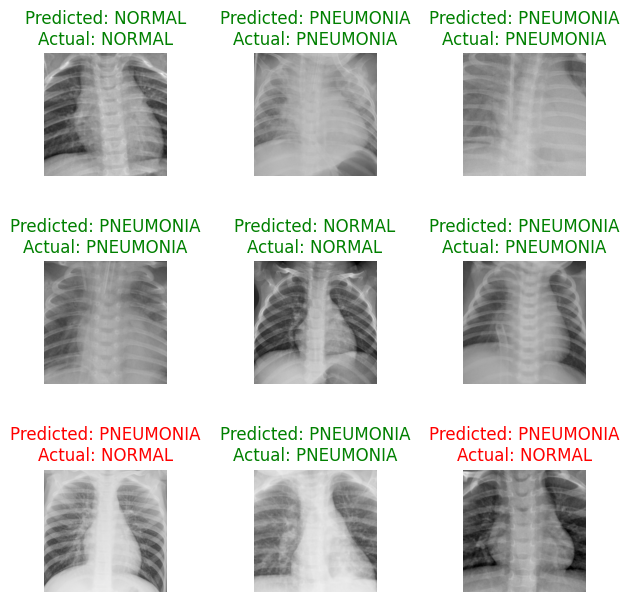

In [20]:
fig, axes = plt.subplots(3,3, figsize=(7, 7))
fig.subplots_adjust(hspace=0.7, wspace=0.7)
x=0
for i in range(3):
    for j in range(3):
        # Get the image and labels
        inp = input_images[x].squeeze()

        true_label = true_labels[x]
        pred_label = pred_labels[x]

        # Normalize the image for display
        inp = inp.cpu().numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        inp = std * inp + mean
        inp = np.clip(inp, 0, 1)

        # Display the image
        axes[i, j].imshow(inp)

        # Set the title with the predicted and actual labels
        title = "Predicted: {}\nActual: {}".format(class_names[pred_label], class_names[true_label])
        color = 'green' if pred_label == true_label else 'red'
        axes[i, j].set_title(title, color=color)

        # Hide the axes
        axes[i, j].axis('off')

        # Move to the next image
        x += 1

plt.show()


In [21]:
print("Total Correct: {} \nTotal Test Images: {}".format(running_correct, running_total))
print("Test Accuracy: ", acc)

Total Correct: 536.0 
Total Test Images: 624.0
Test Accuracy:  0.8589743589743589


### LIME Algorithm

In [ ]:
!pip install lime

## Define LIME-compatible prediction function

### Subtask:
Create a function that preprocesses images and calls the `model_pre` to get prediction probabilities, suitable for LIME.


**Reasoning**:
To prepare the model for LIME explanation, I need to create a `predict_proba` function that handles image preprocessing (tensor conversion, normalization, device transfer) and returns class probabilities.



In [25]:
import torch.nn.functional as F

def predict_proba(images):
    # 1. Convert NumPy array images to PyTorch tensors and adjust shape.
    # LIME typically provides images as (batch_size, H, W, C) NumPy arrays.
    # PyTorch expects (batch_size, C, H, W).
    images_tensor = torch.from_numpy(images).float().permute(0, 3, 1, 2)

    # 2. Move the preprocessed tensors to the appropriate device.
    images_tensor = images_tensor.to(device)

    # 3. Normalize these PyTorch image tensors using the same mean and standard deviation
    # values used during the model's training. Convert numpy mean/std to torch tensors
    # and reshape for broadcasting.
    mean_t = torch.tensor(mean).to(images_tensor.device).view(1, 3, 1, 1)
    std_t = torch.tensor(std).to(images_tensor.device).view(1, 3, 1, 1)

    # Apply normalization (assuming LIME provides images in [0, 1] range as floats)
    images_tensor = (images_tensor - mean_t) / std_t

    # 4. Set the model_pre to evaluation mode.
    model_pre.eval()

    # 5. Pass the preprocessed images through the model_pre to get raw output logits.
    with torch.no_grad():
        outputs = model_pre(images_tensor)

    # 6. Apply a softmax function to the logits to convert them into probabilities.
    probabilities = F.softmax(outputs, dim=1)

    # 7. Move the resulting probabilities back to the CPU and convert them to a NumPy array.
    return probabilities.cpu().numpy()

print("LIME-compatible predict_proba function defined.")

LIME-compatible predict_proba function defined.


## Select and preprocess an image for LIME

### Subtask:
Choose an image from the test set and prepare it for LIME explanation.


**Reasoning**:
To prepare an image for LIME, I will retrieve a single image and its true label from the test dataloader, convert it to a NumPy array, transpose its dimensions, and un-normalize it using the `mean` and `std` values.



In [27]:
inputs, labels = next(iter(dataloaders[TEST]))
image, label = inputs[0], labels[0]

# Convert to NumPy array and transpose dimensions (C, H, W) to (H, W, C)
image_np = image.cpu().numpy().transpose((1, 2, 0))

# Un-normalize the image
mean_np = np.array(mean)
std_np = np.array(std)
lime_image = std_np * image_np + mean_np
lime_image = np.clip(lime_image, 0, 1) #(array, min_value, max_value)

true_label_lime = label.item()

print(f"Selected image shape: {lime_image.shape}")
print(f"True label for LIME image: {class_names[true_label_lime]}")

Selected image shape: (224, 224, 3)
True label for LIME image: NORMAL


## Apply LIME explainer

### Subtask:
Use `lime_image.LimeImageExplainer` to get an explanation for the chosen image.


**Reasoning**:
To apply LIME, I need to import `LimeImageExplainer`, instantiate it, and then call its `explain_instance` method with the prepared image and prediction function.



# Task
Apply the `lime_image.LimeImageExplainer` to get an explanation for the `lime_image` using the `predict_proba` function, and then display the image with the LIME explanation overlayed to visualize the parts of the image that contributed to the model's prediction.

## Apply LIME explainer

### Subtask:
Use `lime_image.LimeImageExplainer` to get an explanation for the chosen image.


**Reasoning**:
To apply LIME, I need to import the explainer, instantiate it, and then call `explain_instance` with the prepared image and prediction function.



**Reasoning**:
The error `RuntimeError: Input type (torch.cuda.DoubleTensor) and weight type (torch.cuda.FloatTensor) should be the same` indicates a data type mismatch between the input tensor to the model and the model's weights. The `predict_proba` function needs to ensure that the input `images_tensor` is consistently of `torch.float32` type before being passed to the model, as the model weights are `float32`.



In [30]:
# import torch.nn.functional as F

# def predict_proba(images):
#     # 1. Convert NumPy array images to PyTorch tensors and adjust shape.
#     # LIME typically provides images as (batch_size, H, W, C) NumPy arrays.
#     # PyTorch expects (batch_size, C, H, W).
#     # Explicitly cast to torch.float32 to match model weights.
#     images_tensor = torch.from_numpy(images).permute(0, 3, 1, 2).to(torch.float32)

#     # 2. Move the preprocessed tensors to the appropriate device.
#     images_tensor = images_tensor.to(device)

#     # 3. Normalize these PyTorch image tensors using the same mean and standard deviation
#     # values used during the model's training. Convert numpy mean/std to torch tensors
#     # and reshape for broadcasting. Ensure mean_t and std_t are also float32.
#     mean_t = torch.tensor(mean, dtype=torch.float32).to(images_tensor.device).view(1, 3, 1, 1)
#     std_t = torch.tensor(std, dtype=torch.float32).to(images_tensor.device).view(1, 3, 1, 1)

#     # Apply normalization (assuming LIME provides images in [0, 1] range as floats)
#     images_tensor = (images_tensor - mean_t) / std_t

#     # 4. Set the model_pre to evaluation mode.
#     model_pre.eval()

#     # 5. Pass the preprocessed images through the model_pre to get raw output logits.
#     with torch.no_grad():
#         outputs = model_pre(images_tensor)

#     # 6. Apply a softmax function to the logits to convert them into probabilities.
#     probabilities = F.softmax(outputs, dim=1)

#     # 7. Move the resulting probabilities back to the CPU and convert them to a NumPy array.
#     return probabilities.cpu().numpy()

# print("LIME-compatible predict_proba function defined.")

LIME-compatible predict_proba function defined.


**Reasoning**:
The previous attempt to generate a LIME explanation failed due to a `RuntimeError` related to tensor data types. The `predict_proba` function has now been corrected to ensure consistent `torch.float32` type for inputs. Therefore, the next step is to re-execute the LIME explanation generation using the fixed `predict_proba` function.



In [31]:
from lime.lime_image import LimeImageExplainer

# Instantiate LimeImageExplainer
explainer = LimeImageExplainer()

# Get the explanation for the chosen image
explanation = explainer.explain_instance(
    image=lime_image,
    classifier_fn=predict_proba,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

print("LIME explanation generated.")

  0%|          | 0/1000 [00:00<?, ?it/s]

LIME explanation generated.


## Visualize LIME explanation

### Subtask:
Display the image with the LIME explanation overlayed.


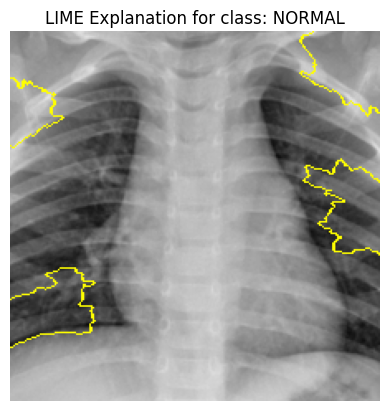

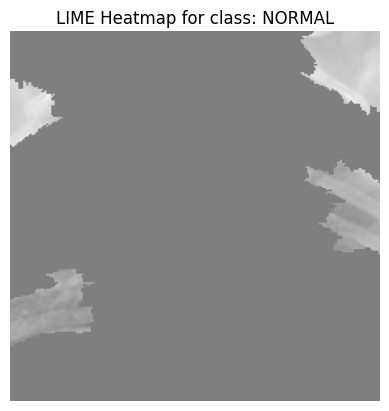

In [32]:
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# Get the image and mask for the top label
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=True
)

# Display the original image with the LIME explanation overlay
plt.imshow(mark_boundaries(lime_image, mask))
plt.title(f'LIME Explanation for class: {class_names[explanation.top_labels[0]]}')
plt.axis('off')
plt.show()

# Optionally, display the heatmap for the explanation
plt.imshow(temp / 2 + 0.5) # Normalize to [0,1] for display
plt.title(f'LIME Heatmap for class: {class_names[explanation.top_labels[0]]}')
plt.axis('off')
plt.show()

In [33]:
lime_images = []
true_labels_lime = []

# Iterate through the test dataloader to get at least three distinct images
# Since batch_size for TEST is 1, we can just iterate 3 times
for i, (inputs, labels) in enumerate(dataloaders[TEST]):
    if i >= 3:  # Get 3 images
        break

    image, label = inputs[0], labels[0]

    # Convert to NumPy array and transpose dimensions (C, H, W) to (H, W, C)
    image_np = image.cpu().numpy().transpose((1, 2, 0))

    # Un-normalize the image
    mean_np = np.array(mean)
    std_np = np.array(std)
    unnormalized_image = std_np * image_np + mean_np
    unnormalized_image = np.clip(unnormalized_image, 0, 1)

    # Store the prepared image and its true label
    lime_images.append(unnormalized_image)
    true_labels_lime.append(label.item())

print(f"Prepared {len(lime_images)} images for LIME explanation.")
for i, img in enumerate(lime_images):
    print(f"Image {i+1} shape: {img.shape}, True label: {class_names[true_labels_lime[i]]}")

Prepared 3 images for LIME explanation.
Image 1 shape: (224, 224, 3), True label: PNEUMONIA
Image 2 shape: (224, 224, 3), True label: PNEUMONIA
Image 3 shape: (224, 224, 3), True label: PNEUMONIA


**Reasoning**:
Now that multiple images are prepared, I need to iterate through each prepared image, generate a LIME explanation using the `explainer` and `predict_proba` function, and then visualize both the LIME boundary overlay and the heatmap for each image.




Explaining image 1 (True label: PNEUMONIA):


  0%|          | 0/1000 [00:00<?, ?it/s]

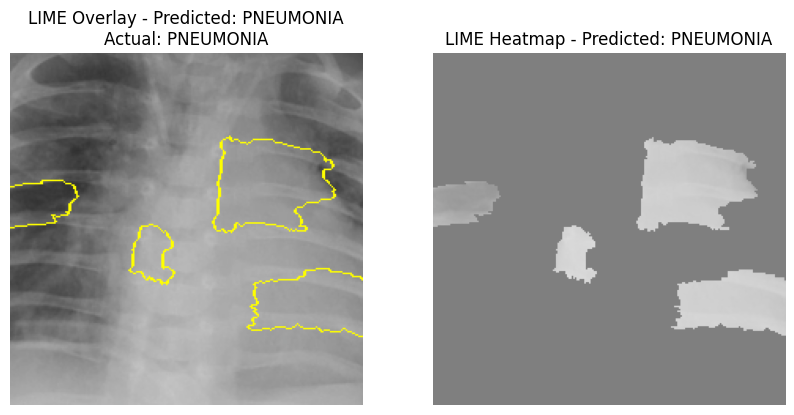


Explaining image 2 (True label: PNEUMONIA):


  0%|          | 0/1000 [00:00<?, ?it/s]

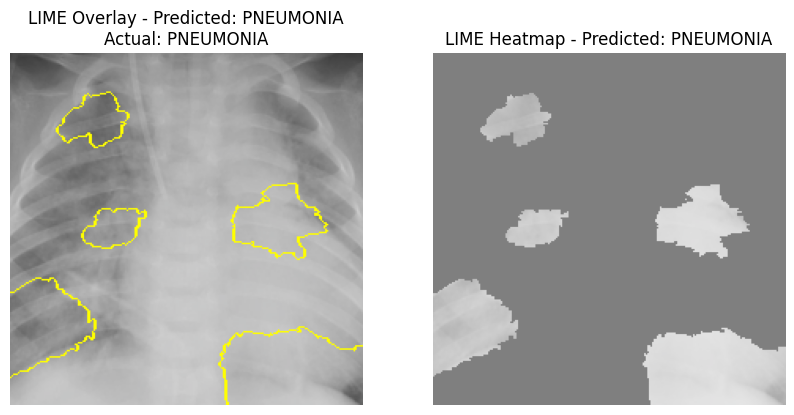


Explaining image 3 (True label: PNEUMONIA):


  0%|          | 0/1000 [00:00<?, ?it/s]

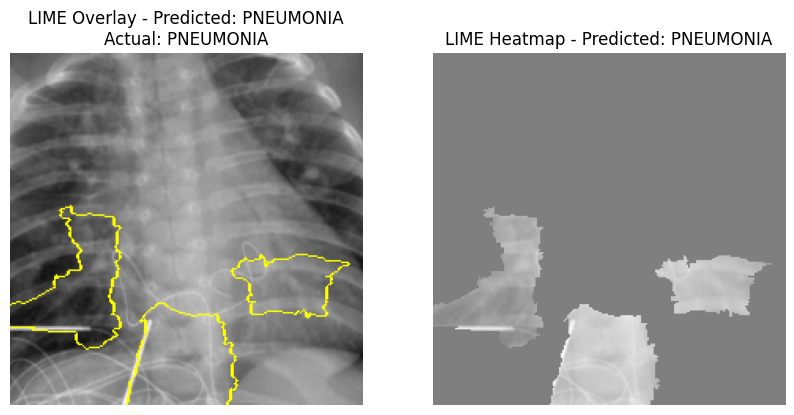

In [34]:
from lime.lime_image import LimeImageExplainer
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# Instantiate LimeImageExplainer
explainer = LimeImageExplainer()

for idx, lime_image_single in enumerate(lime_images):
    true_label_single = true_labels_lime[idx]

    print(f"\nExplaining image {idx+1} (True label: {class_names[true_label_single]}):")

    # Get the explanation for the chosen image
    explanation = explainer.explain_instance(
        image=lime_image_single,
        classifier_fn=predict_proba,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    # Get the image and mask for the top predicted label
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=True
    )

    # Display the original image with the LIME explanation overlay
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(mark_boundaries(lime_image_single, mask))
    plt.title(f'LIME Overlay - Predicted: {class_names[explanation.top_labels[0]]}\nActual: {class_names[true_label_single]}')
    plt.axis('off')

    # Display the heatmap for the explanation
    plt.subplot(1, 2, 2)
    plt.imshow(temp / 2 + 0.5) # Normalize to [0,1] for display
    plt.title(f'LIME Heatmap - Predicted: {class_names[explanation.top_labels[0]]}')
    plt.axis('off')
    plt.show()